### Store Sales Forecasting: Baseline vs Prophet vs LSTM

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def my_rmse(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    squared_errors = (actual - predicted) ** 2
    mean_squared_error_value = squared_errors.sum() / len(actual)
    return mean_squared_error_value ** 0.5

In [ ]:
def my_mae(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    absolute_errors = np.abs(actual - predicted)
    return absolute_errors.sum() / len(actual)

In [ ]:
def my_moving_average(series, window):
    # returns a list, same length as series, with the trailing average
    # first (window-1) values will be NaN since there's not enough history
    result = []
    values = series.values
    for i in range(len(values)):
        if i < window - 1:
            result.append(np.nan)
        else:
            window_slice = values[i - window + 1 : i + 1]
            result.append(window_slice.sum() / window)
    return pd.Series(result, index=series.index)

In [ ]:
class MyMinMaxScaler:
    def __init__(self, feature_range=(0,1)):
        self.min_ = None
        self.max_ = None
        self.range_min, self.range_max = feature_range

    def fit(self, data):
        self.min_ = data.min(axis=0)
        self.max_ = data.max(axis=0)
        return self

    def transform(self, data):
        scaled = (data - self.min_) / (self.max_ - self.min_)
        scaled = scaled * (self.range_max - self.range_min) + self.range_min
        return scaled

    def fit_transform(self, data):
        self.fit(data)
        return self.transform(data)

    def inverse_transform(self, data):
        data = (data - self.range_min) / (self.range_max - self.range_min)
        return data * (self.max_ - self.min_) + self.min_

## 1. EDA

In [ ]:
df = pd.read_csv('train.csv', low_memory=False)
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [ ]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


In [ ]:
store1 = df[df['Store'] == 1].copy()
store1['Date'] = pd.to_datetime(store1['Date'])
store1 = store1.sort_values('Date')
store1.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1016095,1,2,2013-01-01,0,0,0,0,a,1
1014980,1,3,2013-01-02,5530,668,1,0,0,1
1013865,1,4,2013-01-03,4327,578,1,0,0,1
1012750,1,5,2013-01-04,4486,619,1,0,0,1
1011635,1,6,2013-01-05,4997,635,1,0,0,1


In [ ]:
store1 = store1[store1['Open'] == 1]
store1.shape

(781, 9)

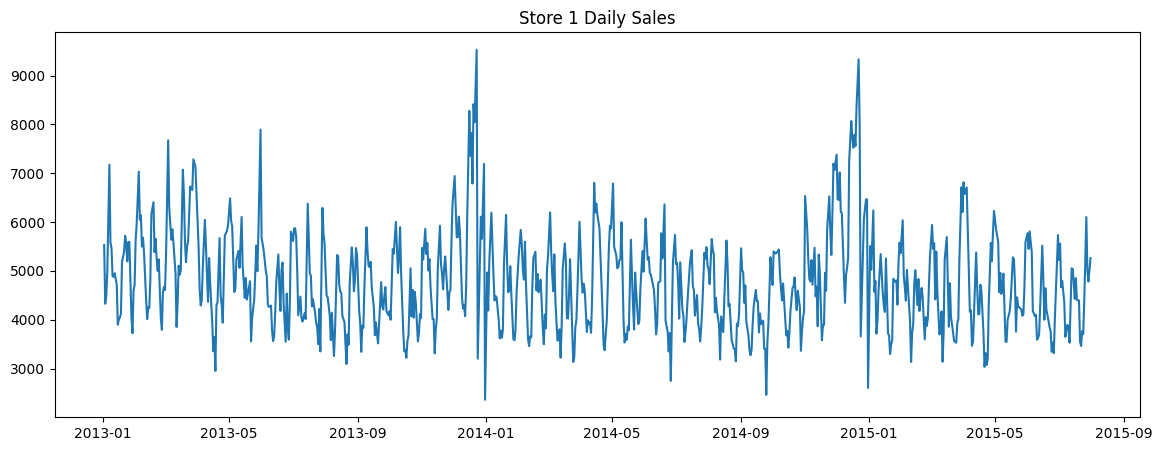

In [ ]:
store1 = store1.set_index('Date')
plt.figure(figsize=(14,5))
plt.plot(store1['Sales'])
plt.title('Store 1 Daily Sales')
plt.show()

/tmp/ipykernel_2815/1425233133.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = store1['Sales'].resample('M').mean()


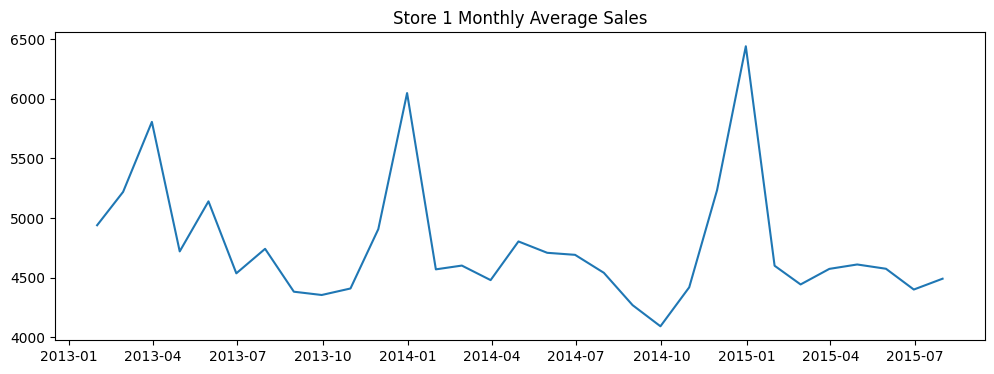

In [ ]:
monthly = store1['Sales'].resample('M').mean()
plt.figure(figsize=(12,4))
plt.plot(monthly)
plt.title('Store 1 Monthly Average Sales')
plt.show()

In [ ]:
store1.groupby('StateHoliday')['Sales'].mean()

,Sales
StateHoliday,
0,4759.096031


In [ ]:
store1['Sales'].describe()

,Sales
count,781.000000
mean,4759.096031
std,1012.106393
min,2362.000000
25%,4000.000000
50%,4647.000000
75%,5348.000000
max,9528.000000


## 2. Baseline models

In [ ]:
sales = store1['Sales']

# Baseline 1: naive - tomorrow = today
naive_pred = sales.shift(1).dropna()
naive_actual = sales[1:]

naive_rmse = my_rmse(naive_actual, naive_pred)
naive_mae = my_mae(naive_actual, naive_pred)
print("Naive baseline RMSE:", naive_rmse)
print("Naive baseline MAE:", naive_mae)

Naive baseline RMSE: 806.0594835529454
Naive baseline MAE: 570.1961538461538


In [ ]:
# Baseline 2: same day last week
naive_week_pred = sales.shift(7).dropna()
naive_week_actual = sales[7:]

naive_week_rmse = my_rmse(naive_week_actual, naive_week_pred)
naive_week_mae = my_mae(naive_week_actual, naive_week_pred)
print("Same-day-last-week baseline RMSE:", naive_week_rmse)
print("Same-day-last-week baseline MAE:", naive_week_mae)

Same-day-last-week baseline RMSE: 1472.0596975768253
Same-day-last-week baseline MAE: 1209.8540051679586


In [ ]:
# Baseline 3: 7-day moving average (using our custom function)
ma_series = my_moving_average(sales, window=7).shift(1).dropna()
ma_actual = sales[ma_series.index]

ma_rmse = my_rmse(ma_actual, ma_series)
ma_mae = my_mae(ma_actual, ma_series)
print("7-day Moving Average baseline RMSE:", ma_rmse)
print("7-day Moving Average baseline MAE:", ma_mae)

7-day Moving Average baseline RMSE: 1027.144887744037
7-day Moving Average baseline MAE: 816.3968253968255


## 3. Classical model: Prophet

In [ ]:
!pip install prophet --quiet

In [ ]:
from prophet import Prophet

prophet_df = store1.reset_index()[['Date', 'Sales']]
prophet_df.columns = ['ds', 'y']
prophet_df.head()

,ds,y
0,2013-01-02,5530
1,2013-01-03,4327
2,2013-01-04,4486
3,2013-01-05,4997
4,2013-01-07,7176


In [ ]:
split_idx = int(len(prophet_df) * 0.80)
prophet_train = prophet_df[:split_idx]
prophet_test = prophet_df[split_idx:]

len(prophet_train), len(prophet_test)

(624, 157)

In [ ]:
prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
prophet_model.fit(prophet_train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = prophet_test[['ds']]
forecast = prophet_model.predict(future)
forecast[['ds', 'yhat']].head()

,ds,yhat
0,2015-01-23,4507.365696
1,2015-01-24,4733.628760
2,2015-01-26,5092.036893
3,2015-01-27,4624.655997
4,2015-01-28,4550.454482


In [ ]:
prophet_rmse = my_rmse(prophet_test['y'].values, forecast['yhat'].values)
prophet_mae = my_mae(prophet_test['y'].values, forecast['yhat'].values)
print("Prophet RMSE:", prophet_rmse)
print("Prophet MAE:", prophet_mae)

Prophet RMSE: 851.3225800611672
Prophet MAE: 688.5965135896507


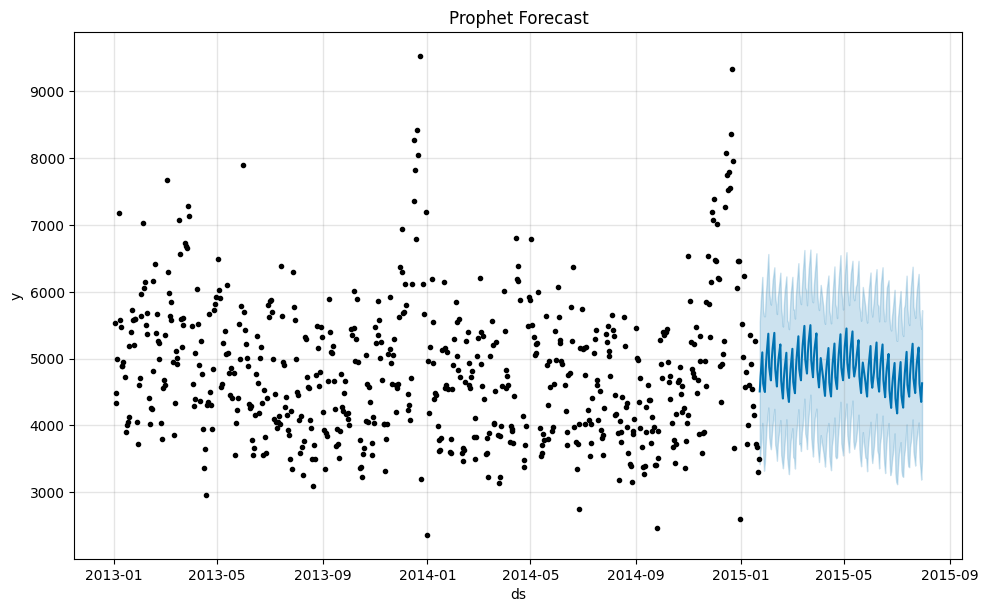

In [ ]:
prophet_model.plot(forecast)
plt.title('Prophet Forecast')
plt.show()

## 4. Deep learning model: Stacked LSTM

In [ ]:
scaler = MyMinMaxScaler(feature_range=(0,1))
sales_scaled = scaler.fit_transform(sales.values.reshape(-1,1))

In [ ]:
training_size = int(len(sales_scaled) * 0.80)
train_data = sales_scaled[0:training_size]
test_data = sales_scaled[training_size:]

training_size, len(test_data)

(624, 157)

In [ ]:
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        dataX.append(dataset[i:(i+time_step), 0])
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

In [ ]:
time_step = 30
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

X_train.shape, X_test.shape

((593, 30, 1), (126, 30, 1))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0423 - val_loss: 0.0170
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0208 - val_loss: 0.0157
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0202 - val_loss: 0.0157
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0204 - val_loss: 0.0159
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0205 - val_loss: 0.0157
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0203 - val_loss: 0.0157
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0203 - val_loss: 0.0158
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0199 - val_loss: 0.0178
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0204 - val_loss: 0.0164
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0201 - val_loss: 0.0170
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0204 - val_loss: 0.0161
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

In [ ]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
lstm_rmse = my_rmse(y_test_actual, test_predict)
lstm_mae = my_mae(y_test_actual, test_predict)
print("LSTM RMSE:", lstm_rmse)
print("LSTM MAE:", lstm_mae)

LSTM RMSE: 601.0352642796493
LSTM MAE: 483.7883496144934


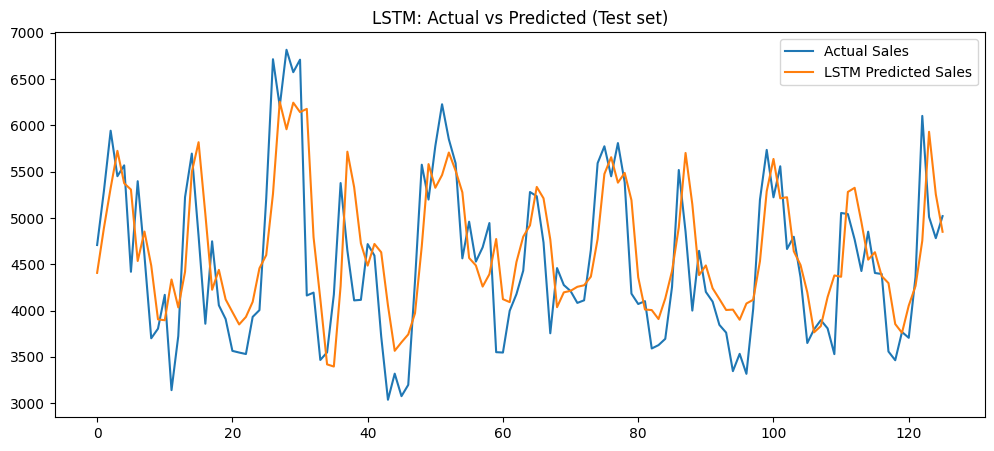

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual Sales')
plt.plot(test_predict, label='LSTM Predicted Sales')
plt.legend()
plt.title('LSTM: Actual vs Predicted (Test set)')
plt.show()

## 5. Compare all models

In [ ]:
results = pd.DataFrame({
    'Model': ['Naive (t-1)', 'Naive (t-7)', 'Moving Average (7-day)', 'Prophet', 'LSTM'],
    'RMSE': [naive_rmse, naive_week_rmse, ma_rmse, prophet_rmse, lstm_rmse],
    'MAE': [naive_mae, naive_week_mae, ma_mae, prophet_mae, lstm_mae]
})
results = results.sort_values('RMSE')
results

,Model,RMSE,MAE
4,LSTM,601.035264,483.788350
0,Naive (t-1),806.059484,570.196154
3,Prophet,851.322580,688.596514
2,Moving Average (7-day),1027.144888,816.396825
1,Naive (t-7),1472.059698,1209.854005


## 6. Save best model for deployment

In [ ]:
import pickle
model.save('sales_lstm_model.h5')
pickle.dump(scaler, open('sales_scaler.pkl','wb'))